# Course 1 — Regularization
===========================

Regularization is a technique used to prevent overfitting by penalizing large weights in the model. It helps the model generalize better to unseen test data.

### In this notebook, we will explore:
1. **Overfitting**: Visualizing how high-degree polynomial models overfit simple sine-wave data.
2. **Regularization Comparison**: Evaluating L2 (Ridge), L1 (Lasso), and ElasticNet regularizers.
3. **Tuning Regularization Strength**: Finding the optimal value for the regularization hyperparameter $\lambda$ (known as `alpha` in Scikit-Learn).

In [ ]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


## 1. Polynomial Regression & Overfitting

We generate 20 noisy samples from a sine wave. When fitting polynomials of varying degrees:
- **Degree 1 (Underfit)**: High bias, cannot capture the curve.
- **Degree 3 (Good fit)**: Captures the underlying sine wave shape well.
- **Degree 15 (Overfit)**: High variance, captures random noise in the training set and generalizes poorly (huge test MSE).

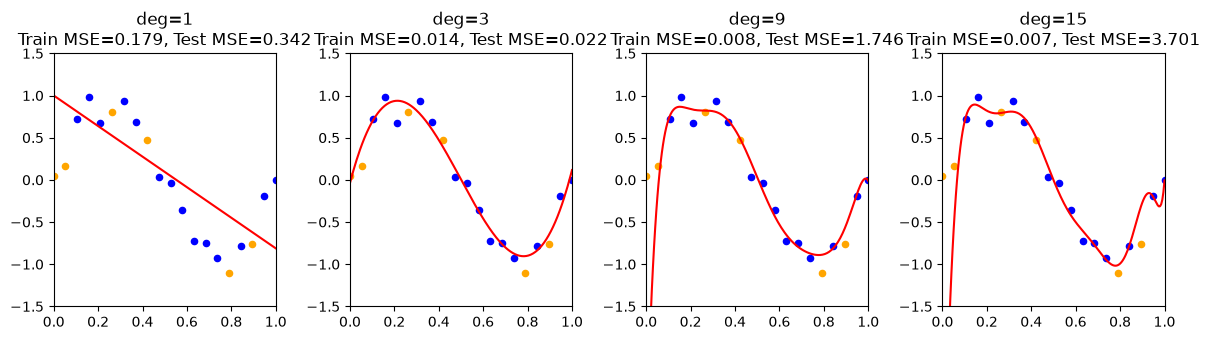

In [7]:
# ── High-degree polynomial (prone to overfitting) ─────────────────────

rng = np.random.default_rng(42)
X = np.linspace(0, 1, 20)
y = np.sin(2 * np.pi * X) + rng.normal(0, 0.15, size=20)
X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Visualise different degrees
degrees = [1, 3, 9, 15]
plt.figure(figsize=(12, 3.5))
X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

for i, deg in enumerate(degrees):
    ax = plt.subplot(1, 4, i + 1)
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_plot)
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    ax.scatter(X_train, y_train, c="b", s=20, label="Train")
    ax.scatter(X_test, y_test, c="orange", s=20, label="Test")
    ax.plot(X_plot, y_pred, "r-", linewidth=1.5)
    ax.set_title(f"deg={deg}\nTrain MSE={train_mse:.3f}, Test MSE={test_mse:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

## 2. Ridge, Lasso, and ElasticNet Regularizers

We can regularize our Degree 15 polynomial model by adding a penalty term to our loss function. Here are the three primary types:

### L2 Regularization (Ridge Regression)
Adds the squared magnitude of weights as a penalty:
$$J(w, b) = \text{Loss} + \frac{\lambda}{2m} \sum_{j=1}^n w_j^2$$
This shrinks weights $w_j$ towards $0$ but keeps all of them non-zero.

### L1 Regularization (Lasso Regression)
Adds the absolute magnitude of weights as a penalty:
$$J(w, b) = \text{Loss} + \frac{\lambda}{m} \sum_{j=1}^n |w_j|$$
This forces some weights to be exactly $0$, rendering the model sparse and acting as an automatic feature selector.

### ElasticNet
Combines both L1 and L2 penalties, controlled by a mixing ratio $r$ (`l1_ratio`):
$$J(w, b) = \text{Loss} + r \cdot \frac{\lambda}{m} \sum_{j=1}^n |w_j| + (1 - r) \cdot \frac{\lambda}{2m} \sum_{j=1}^n w_j^2$$

In [8]:
# ── Ridge vs Lasso vs ElasticNet ──────────────────────────────────────

print("── Regularisation Comparison (degree=15, λ=0.01) ──")

deg = 15
poly = PolynomialFeatures(deg)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

models = {
    "Linear (no reg)": LinearRegression(),
    "Ridge (L2)":      Ridge(alpha=0.01),
    "Lasso (L1)":      Lasso(alpha=0.01),
    "ElasticNet":      ElasticNet(alpha=0.01, l1_ratio=0.5),
}

for name, mdl in models.items():
    mdl.fit(X_train_poly, y_train)
    train_mse = mean_squared_error(y_train, mdl.predict(X_train_poly))
    test_mse  = mean_squared_error(y_test, mdl.predict(X_test_poly))
    nz = np.sum(np.abs(mdl.coef_) > 1e-6)
    print(f"  {name:20s}  Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}, "
          f"Non-zero coefs={nz}")

── Regularisation Comparison (degree=15, λ=0.01) ──
  Linear (no reg)       Train MSE=0.0071, Test MSE=3.7009, Non-zero coefs=15
  Ridge (L2)            Train MSE=0.0249, Test MSE=0.2998, Non-zero coefs=15
  Lasso (L1)            Train MSE=0.0619, Test MSE=0.4515, Non-zero coefs=3
  ElasticNet            Train MSE=0.0552, Test MSE=0.3299, Non-zero coefs=12


## 3. Tuning the Regularization Strength $\lambda$

The hyperparameter $\lambda$ controls the trade-off between fitting the training data and keeping the weights small:
- **$\lambda$ too small (low regularization)**: The model is complex and overfits (high variance).
- **$\lambda$ too large (high regularization)**: The model is overly constrained and underfits (high bias).
- **Optimal $\lambda$**: Minimizes generalization error (lowest validation or test MSE).


── Effect of λ (alpha) on Ridge ──


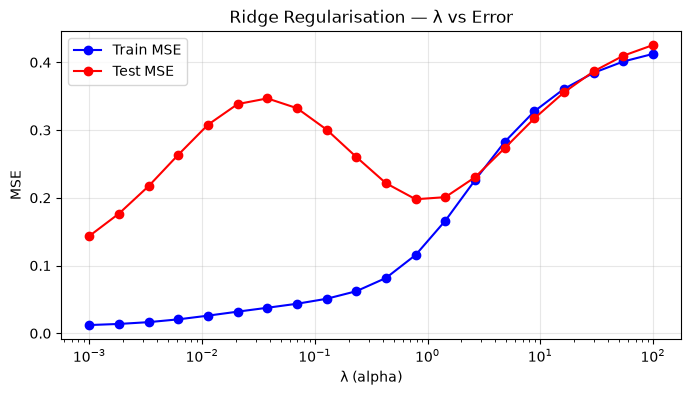

  Best λ (lowest test MSE): 0.0010


In [9]:
# ── Effect of λ (Regularization Strength) ────────────────────────────

print("\n── Effect of λ (alpha) on Ridge ──")
lambdas = np.logspace(-3, 2, 20)
train_errs, test_errs = [], []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_poly, y_train)
    train_errs.append(mean_squared_error(y_train, ridge.predict(X_train_poly)))
    test_errs.append(mean_squared_error(y_test, ridge.predict(X_test_poly)))

plt.figure(figsize=(8, 4))
plt.semilogx(lambdas, train_errs, "b-o", label="Train MSE")
plt.semilogx(lambdas, test_errs, "r-o", label="Test MSE")
plt.xlabel("λ (alpha)")
plt.ylabel("MSE")
plt.title("Ridge Regularisation — λ vs Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_lam = lambdas[np.argmin(test_errs)]
print(f"  Best λ (lowest test MSE): {best_lam:.4f}")

## Key Takeaways

- **Overfitting (High Variance)**: Characterized by very low training error but high test error.
- **L2 Regularization (Ridge)**: Adds a penalty proportional to the sum of squared weights ($\frac{\lambda}{2m} \|w\|^2_2$). It shrinks weights close to zero but keeps all features active.
- **L1 Regularization (Lasso)**: Adds a penalty proportional to the sum of absolute weights ($\frac{\lambda}{m} \|w\|_1$). It creates sparse weight vectors, forcing irrelevant feature weights to exactly $0$.
- **ElasticNet**: Combines L1 and L2 terms to leverage the strengths of both (e.g. grouping effect of L2 while retaining sparse selection of L1).
- **Strength Tuning**: Large $\lambda$ increases bias (underfit); small $\lambda$ increases variance (overfit). The optimal $\lambda$ is usually found via cross-validation.

In [10]:
# ── Key Takeaways ─────────────────────────────────────────────────────
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Overfitting: low train error, high test error                ║
║ • L2 (Ridge):    adds λ·||w||² — shrinks weights, no zeros     ║
║ • L1 (Lasso):    adds λ·||w||₁ — drives some weights to 0      ║
║ • ElasticNet:    blends L1 + L2 (l1_ratio controls mix)        ║
║ • λ↑ → more regularization (underfitting risk)                 ║
║ • λ↓ → less regularization (overfitting risk)                  ║
║ • Choose λ via cross-validation on validation set              ║
╚════════════════════════════════════════════════════════════════╝
""")


╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Overfitting: low train error, high test error                ║
║ • L2 (Ridge):    adds λ·||w||² — shrinks weights, no zeros     ║
║ • L1 (Lasso):    adds λ·||w||₁ — drives some weights to 0      ║
║ • ElasticNet:    blends L1 + L2 (l1_ratio controls mix)        ║
║ • λ↑ → more regularization (underfitting risk)                 ║
║ • λ↓ → less regularization (overfitting risk)                  ║
║ • Choose λ via cross-validation on validation set              ║
╚════════════════════════════════════════════════════════════════╝

